In [62]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pygments.token import is_token_subtype
from sympy import true
%matplotlib inline

In [63]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [64]:
len(words)

32033

In [65]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}

In [66]:
blockSize = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * blockSize
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context[:blockSize])
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [67]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [68]:
Xtr.dtype, Xtr.shape, Ytr.dtype, Ytr.shape

(torch.int64, torch.Size([182625, 3]), torch.int64, torch.Size([182625]))

In [69]:
torch.manual_seed(3293434938)
C = torch.randn((27,2))
C

tensor([[-1.1679, -0.0819],
        [-0.3958,  1.0380],
        [ 0.1166,  1.4999],
        [-0.3855,  0.0414],
        [-0.7516,  0.2199],
        [-0.0957,  0.1399],
        [-2.3310, -0.2150],
        [ 0.4109,  1.2314],
        [ 1.0980,  0.7194],
        [-0.3828, -0.2945],
        [ 0.3810, -0.0644],
        [ 0.3153, -0.2206],
        [-0.6621,  0.2443],
        [-0.1506,  0.0776],
        [ 0.2795, -1.1779],
        [ 0.9392, -0.2760],
        [-0.4732,  0.1555],
        [ 0.1249, -0.1345],
        [-0.8901,  0.2616],
        [-0.0279,  0.7322],
        [ 0.2642, -1.7312],
        [-0.3497,  1.0910],
        [ 0.0260, -0.0875],
        [ 1.4770,  0.1238],
        [-0.1362,  0.1743],
        [ 0.9194, -0.0971],
        [ 1.0622, -1.5813]])

In [70]:
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 2])

In [71]:
torch.manual_seed(3293434938)
W1 = torch.randn((6,100))
torch.manual_seed(3293434938)
b1 = torch.randn(100)

In [72]:
emb.view(-1, 6).shape

torch.Size([182625, 6])

In [73]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [74]:
h

tensor([[-0.5574, -0.9375, -0.9389,  ...,  0.8997,  0.5184,  0.9999],
        [ 0.5604,  0.7071, -0.8074,  ...,  0.9675,  0.9109,  1.0000],
        [-0.6250, -0.1117,  0.9896,  ...,  0.5643,  0.6577,  0.9880],
        ...,
        [-0.9931, -0.9623, -0.8526,  ...,  0.9869,  0.4449, -0.3703],
        [-0.8594, -0.5240, -0.1513,  ...,  0.9257,  0.6415,  0.9999],
        [ 0.8485, -0.7651, -0.9863,  ...,  0.9972, -0.0282,  0.9841]])

In [75]:
h.shape

torch.Size([182625, 100])

In [76]:
torch.manual_seed(3293434938)
W2 = torch.randn((100,27))
torch.manual_seed(3293434938)
b2 = torch.randn(27)

In [77]:
logits = h @ W2 + b2

In [78]:
logits.shape

torch.Size([182625, 27])

In [79]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [80]:
prob.shape

torch.Size([182625, 27])

In [81]:
loss_nll = -prob[torch.arange(Ytr.shape[0]), Ytr].log().mean()
loss_nll

tensor(15.7269)

In [84]:
loss_ce = F.cross_entropy(logits, Ytr)
loss_ce

tensor(15.7269)

In [86]:
(loss_nll - loss_ce).abs()
torch.allclose(loss_nll, loss_ce, atol=1e-5)

True

- 训练集训练参数
- 验证集调整超参数
- 测试集评估模型性能

In [119]:
g = torch.Generator().manual_seed(349343293)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
paramters = [C, W1, b1, W2, b2]

In [120]:
sum(p.nelement() for p in paramters)

3481

In [121]:
for p in paramters:
    p.requires_grad_(True)

In [122]:
# 固定32个序列训练
ix = torch.randint(0, Xtr.shape[0], (32,))
for i in range(10000):
    # forward pass
    emp = C[Xtr[ix]]
    h = torch.tanh(emp.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    print(i, loss.item())

    for p in paramters:
        p.grad = None
    loss.backward()

    for p in paramters:
        p.data += -0.1*p.grad

0 20.21224021911621
1 17.32675552368164
2 15.047931671142578
3 12.98126220703125
4 11.19826602935791
5 9.768068313598633
6 8.591675758361816
7 7.69305419921875
8 6.9222307205200195
9 6.258258819580078
10 5.680037498474121
11 5.169547080993652
12 4.711663246154785
13 4.29276704788208
14 3.9069197177886963
15 3.5512733459472656
16 3.225743293762207
17 2.9320785999298096
18 2.6731743812561035
19 2.4490249156951904
20 2.2533562183380127
21 2.078425884246826
22 1.9190775156021118
23 1.7725061178207397
24 1.6376115083694458
25 1.5146209001541138
26 1.4046216011047363
27 1.3080393075942993
28 1.22327721118927
29 1.14789879322052
30 1.0801197290420532
31 1.0192838907241821
32 0.965792715549469
33 0.922450840473175
34 0.8904368281364441
35 0.8795337080955505
36 0.8505529761314392
37 0.8358736634254456
38 0.7759507894515991
39 0.7486457824707031
40 0.7129384875297546
41 0.6967640519142151
42 0.6741204261779785
43 0.6634374856948853
44 0.6480501890182495
45 0.6404556035995483
46 0.629077255725860

In [148]:
g_batch = torch.Generator().manual_seed(42)
batches = torch.randint(0, Xtr.shape[0], (20000, 32), generator=g_batch)

In [149]:
# baseline
gb = torch.Generator().manual_seed(349343293)
Cb = torch.randn((27,2), generator=gb)
W1b = torch.randn((6,100), generator=gb)
b1b = torch.randn(100, generator=gb)
W2b = torch.randn((100,27), generator=gb)
b2b = torch.randn(27, generator=gb)
paramtersb = [Cb, W1b, b1b, W2b, b2b]

In [150]:
#  随机32个训练
for p in paramtersb:
    p.requires_grad_(True)
train_loss = None
loss_baseline = None
for i in range(20000):
    lr = 0.1 if i<10000 else 0.01
    ix = batches[i]
    # forward pass
    emp = Cb[Xtr[ix]]
    h = torch.tanh(emp.view(-1, 6) @ W1b + b1b)
    logits = h @ W2b + b2b
    train_loss = F.cross_entropy(logits, Ytr[ix])
    print(i, train_loss.item())

    for p in paramtersb:
        p.grad = None
    train_loss.backward()

    for p in paramtersb:
        p.data += -lr*p.grad

print(f'{train_loss=}')

with torch.no_grad():
    emp = Cb[Xdev]
    h = torch.tanh(emp.view(-1, 6) @ W1b + b1b)
    logits = h @ W2b + b2b
    loss_baseline = F.cross_entropy(logits, Ydev)
    print(f'{loss_baseline.item()=}')

0 19.034141540527344
1 14.41228199005127
2 16.989990234375
3 14.212580680847168
4 14.478503227233887
5 11.40701675415039
6 11.673054695129395
7 13.986587524414062
8 10.5703763961792
9 9.055683135986328
10 11.54715633392334
11 9.989653587341309
12 8.5458402633667
13 9.488525390625
14 10.002902030944824
15 9.497721672058105
16 7.575321197509766
17 7.5119524002075195
18 9.178424835205078
19 8.419473648071289
20 6.541316509246826
21 6.898777008056641
22 6.991707801818848
23 6.610067844390869
24 6.397793292999268
25 5.3880133628845215
26 6.415262222290039
27 7.288121223449707
28 6.607104778289795
29 6.042904853820801
30 6.932595252990723
31 5.711805820465088
32 7.221765995025635
33 5.568310260772705
34 4.975045680999756
35 4.7346954345703125
36 4.831508636474609
37 4.654577255249023
38 5.141079425811768
39 5.924746036529541
40 5.068319797515869
41 6.2875447273254395
42 4.099045753479004
43 4.742404937744141
44 4.165827751159668
45 4.685290813446045
46 4.515170574188232
47 5.1987080574035645

In [160]:
C_baseline = Cb.detach().clone()

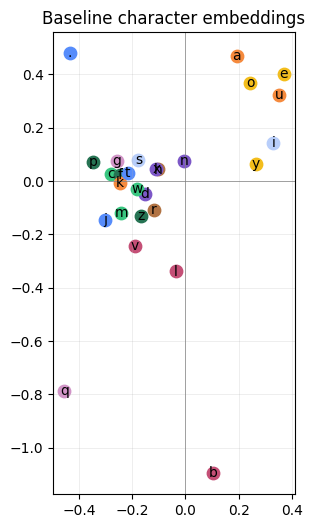

In [161]:
plt.figure(figsize=(6, 6))

for i in range(C_baseline.shape[0]):
    x, y = C_baseline[i].tolist()
    plt.scatter(x, y, s=80)
    plt.text(x, y, itos[i], ha='center', va='center')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Baseline character embeddings')
plt.show()

In [153]:
# hidden layer = 300
g_h300 = torch.Generator().manual_seed(349343293)
C_h300 = torch.randn((27,2), generator=g_h300)
W1_h300 = torch.randn((6,300), generator=g_h300)
b1_h300 = torch.randn(300, generator=g_h300)
W2_h300 = torch.randn((300,27), generator=g_h300)
b2_h300 = torch.randn(27, generator=g_h300)
paramters_h300 = [C_h300, W1_h300, b1_h300, W2_h300, b2_h300]

In [154]:
sum (p.nelement() for p in paramters_h300)

10281

In [155]:
# hidden layer = 300 随机32个训练
loss_h300 = None
for p in paramters_h300:
    p.requires_grad_(True)

train_loss = None
for i in range(20000):
    lr = 0.1 if i<10000 else 0.01
    ix = batches[i]

    # forward pass
    emp = C_h300[Xtr[ix]]
    h = torch.tanh(emp.view(-1, 6) @ W1_h300 + b1_h300)
    logits = h @ W2_h300 + b2_h300
    train_loss = F.cross_entropy(logits, Ytr[ix])
    print(i, train_loss.item())

    for p in paramters_h300:
        p.grad = None
    train_loss.backward()

    for p in paramters_h300:
        p.data += -lr*p.grad

print(f'{train_loss=}')

with torch.no_grad():
    emp = C_h300[Xdev]
    h = torch.tanh(emp.view(-1, 6) @ W1_h300 + b1_h300)
    logits = h @ W2_h300 + b2_h300
    loss_h300 = F.cross_entropy(logits, Ydev)
    print(f'{loss_h300.item()=}')

0 25.451330184936523
1 21.632415771484375
2 20.886987686157227
3 16.33845329284668
4 16.89879608154297
5 19.76752281188965
6 16.5004940032959
7 14.368097305297852
8 14.64952564239502
9 14.024112701416016
10 13.890663146972656
11 14.882087707519531
12 12.780350685119629
13 12.998700141906738
14 13.515959739685059
15 12.796480178833008
16 13.729864120483398
17 11.210771560668945
18 12.062675476074219
19 10.253695487976074
20 10.48450756072998
21 11.857314109802246
22 8.64267349243164
23 7.823810577392578
24 9.311006546020508
25 9.504995346069336
26 7.987893581390381
27 7.221407890319824
28 8.351760864257812
29 8.740097045898438
30 6.784945011138916
31 7.417677879333496
32 7.82554817199707
33 7.6875104904174805
34 8.04081916809082
35 7.491438865661621
36 7.171701431274414
37 8.023164749145508
38 9.231217384338379
39 6.876796245574951
40 5.391870975494385
41 6.2724080085754395
42 5.150575160980225
43 5.807493209838867
44 6.106547832489014
45 6.513784408569336
46 8.135092735290527
47 7.1893

In [156]:
# embedding=10
g_emb10 = torch.Generator().manual_seed(349343293)
C_emb10 = torch.randn((27,10), generator=g_emb10)
W1_emb10 = torch.randn((30,100), generator=g_emb10)
b1_emb10 = torch.randn(100, generator=g_emb10)
W2_emb10 = torch.randn((100,27), generator=g_emb10)
b2_emb10 = torch.randn(27, generator=g_emb10)
paramters_emb10 = [C_emb10, W1_emb10, b1_emb10, W2_emb10, b2_emb10]

In [157]:
sum(p.nelement() for p in paramters_emb10)

6097

In [158]:
# embedding=10 随机32个训练
loss_emb10 = None
for p in paramters_emb10:
    p.requires_grad_(True)

train_loss = None
for i in range(20000):
    lr = 0.1 if i<10000 else 0.01
    ix = batches[i]
    # forward pass
    emp = C_emb10[Xtr[ix]]
    h = torch.tanh(emp.view(-1, 30) @ W1_emb10 + b1_emb10)
    logits = h @ W2_emb10 + b2_emb10
    train_loss = F.cross_entropy(logits, Ytr[ix])
    print(i, train_loss.item())

    for p in paramters_emb10:
        p.grad = None
    train_loss.backward()

    for p in paramters_emb10:
        p.data += -lr*p.grad

print(f'{train_loss=}')

with torch.no_grad():
    emp = C_emb10[Xdev]
    h = torch.tanh(emp.view(-1, 30) @ W1_emb10 + b1_emb10)
    logits = h @ W2_emb10 + b2_emb10
    loss_emb10 = F.cross_entropy(logits, Ydev)
    print(f'{loss_emb10.item()=}')

0 19.576662063598633
1 16.13895034790039
2 18.706432342529297
3 18.01029396057129
4 11.7612886428833
5 17.117084503173828
6 13.75596809387207
7 13.6930513381958
8 12.101634979248047
9 13.966612815856934
10 14.103592872619629
11 16.689971923828125
12 11.912779808044434
13 13.964702606201172
14 15.365107536315918
15 12.577532768249512
16 9.43819808959961
17 13.594578742980957
18 13.768162727355957
19 14.664864540100098
20 12.356348991394043
21 11.583645820617676
22 9.984443664550781
23 9.4310884475708
24 10.868219375610352
25 10.971211433410645
26 12.00543212890625
27 10.860108375549316
28 12.697619438171387
29 12.328206062316895
30 11.079927444458008
31 10.13115406036377
32 14.084718704223633
33 9.859419822692871
34 13.754240036010742
35 9.518600463867188
36 10.93244457244873
37 9.166300773620605
38 13.11510944366455
39 8.74299144744873
40 12.486647605895996
41 10.322555541992188
42 6.894996643066406
43 8.902231216430664
44 8.210659980773926
45 5.906596660614014
46 12.32015323638916
47 

In [159]:
print(f'{loss_baseline=}, {loss_h300=}, {loss_emb10=}')

loss_baseline=tensor(2.3846), loss_h300=tensor(2.3673), loss_emb10=tensor(2.3042)


In [163]:
with torch.no_grad():
    emp = C_emb10[Xte]
    h = torch.tanh(emp.view(-1, 30) @ W1_emb10 + b1_emb10)
    logits = h @ W2_emb10 + b2_emb10
    loss_te = F.cross_entropy(logits, Yte)
    print(f'{loss_te.item()=}')

loss_te.item()=2.310077428817749


In [172]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * blockSize
    while True:
        emb = C_emb10[torch.tensor(context)]
        h = torch.tanh(emb.view(-1, 30) @ W1_emb10 + b1_emb10)
        logits = h @ W2_emb10 + b2_emb10
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

careah.
amelle.
khi.
mrix.
taty.
sacella.
jazonte.
ameryn.
jarqui.
nelmara.
chaiir.
kaleigy.
ham.
joce.
quinn.
sulin.
alian.
quis.
elo.
dearixip.
